In [1]:
from amocatlas import read
from amoc_analysis import data
import matplotlib.pyplot as plt
%load_ext autoreload

In [41]:
# Read dataset
ds = read.move()   # 16N (also: read.osnap(), read.move(),read.samba(), read.fw2015(), ...)
ds.MOC

Loading 1 MOVE 16°N dataset(s):
  0. OS_MOVE_20000206-20221014_DPR_VOLUMETRANSPORT.nc: MOVE transport time series



<xarray.DataArray 'MOC' (TIME: 4164)> Size: 33kB
array([nan, nan, nan, ..., nan, nan, nan], shape=(4164,))
Coordinates:
  * TIME       (TIME) datetime64[ns] 33kB 2000-02-06 2000-02-08 ... NaT NaT
    LATITUDE   float64 8B ...
    LONGITUDE  float64 8B ...
    PRESSURE   float64 8B ...
Attributes:
    long_name:            MOC_z
    standard_name:        ocean_meridional_overturning_transport
    units:                Sverdrup
    geometry:             location_geometry
    ancillary_variables:  transport_component_internal transport_component_in...
    valid_min:            -100.0
    valid_max:            100.0
    comment:              Computed as the sum of multiple components, which a...
    description:          Ocean volume transport across the MOVE line

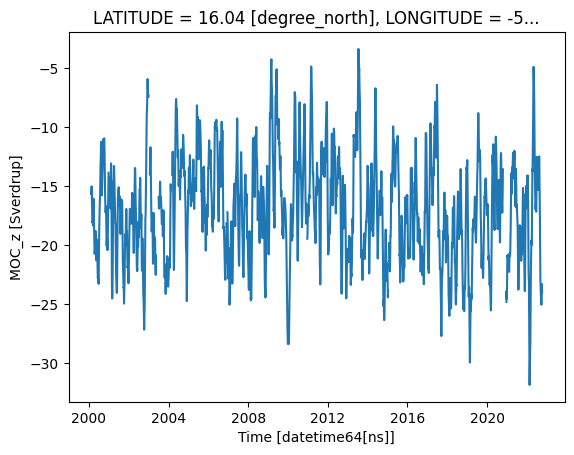

In [3]:
moc = ds.MOC # overturning transport (Sv)
# x = moc.interpolate_na("time").values # fill gaps
fs = 0.5 # samples/day (48-hour grid)

moc.plot()

## Part A - Characterise the series (time domain)

1
- record length:
    - 2000-02-06 to 2022-10-14 (plus 20 values of NaT)
    - 4164 observations (22.7 years)
- sampling interval: 48 h
- number/pattern of missing values: 180 out of 4164
- state gap-handling and why

2
- mean: -16.9
- std: 4.5
- min: -31.9
- max: -3.3
- range: 28.5
- distribution (histogram)

In [46]:
%autoreload
from amoc_analysis.spectra_filtering.analysis import summary_stats

stats = summary_stats(ds.MOC)

stats

{'n': 4164,
 'n_missing': 180,
 'mean': np.float64(-16.920485508780807),
 'std': np.float64(4.486071942040062),
 'median': np.float64(-16.97935440058517),
 'min': np.float64(-31.85568629885044),
 'max': np.float64(-3.339813335100806),
 'range': np.float64(28.515872963749633)}

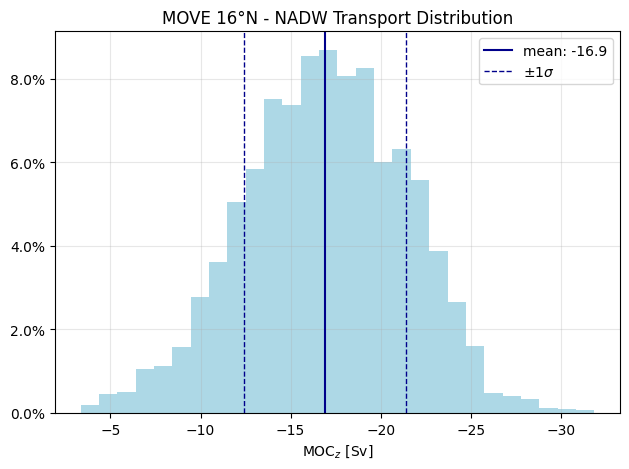

In [97]:
from matplotlib.ticker import PercentFormatter

fig, ax = plt.subplots(tight_layout=True)

# Plot histogram
plt.hist(ds.MOC, bins=int(stats['range']), density=True, color='lightblue')
# plt.hist(ds.MOC, bins=10, density=True, color='darkblue')

# Plot mean
plt.axvline(x=stats['mean'], c='darkblue', label=f'mean: {stats['mean']:.1f}')
plt.axvline(x=stats['mean']+stats['std'], c='darkblue', ls='dashed', lw=1, label=r'$\pm 1 \sigma$')
plt.axvline(x=stats['mean']-stats['std'], c='darkblue', ls='dashed', lw=1)

# Figure settings
plt.title('MOVE 16°N - NADW Transport Distribution')
plt.xlabel(r'MOC$_z$ [Sv]')
plt.grid(alpha=0.3)
plt.legend()

# Invert x-axis to show increasing southward flow
ax.xaxis.set_inverted(True)

# Format y-axis ticks as percentages
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

# Save and show fig
plt.savefig('../plots/hist.pdf', bbox_inches='tight')
plt.savefig('../plots/hist.png', bbox_inches='tight')
plt.show()

In [42]:
# %autoreload
# from amoc_analysis.spectra_filtering.analysis import seasonal_cycle

# clim_months = seasonal_cycle(time=ds.TIME, values=ds.MOC, by='month')
# clim_doy    = seasonal_cycle(time=ds.TIME, values=ds.MOC, by='dayofyear')

# # Compute seasonal range
# seasonal_range_months = clim_months["mean"].max() - clim_months["mean"].min()
# print(seasonal_range_months)

# clim_months.plot()
# plt.ylabel('MOC [Sv]')
# plt.xlabel('month')

# clim_doy.plot()
# plt.xlabel('dayofyear')
# plt.ylabel('MOC [Sv]')
# plt.savefig('../plots/fig1.png')
# plt.savefig('../plots/fig1.pdf')
# plt.show()

In [43]:
# %autoreload
# from amoc_analysis.spectra_filtering.analysis import decorrelation_timescale

# decorrelation_timescale(ds.MOC, dt=1)

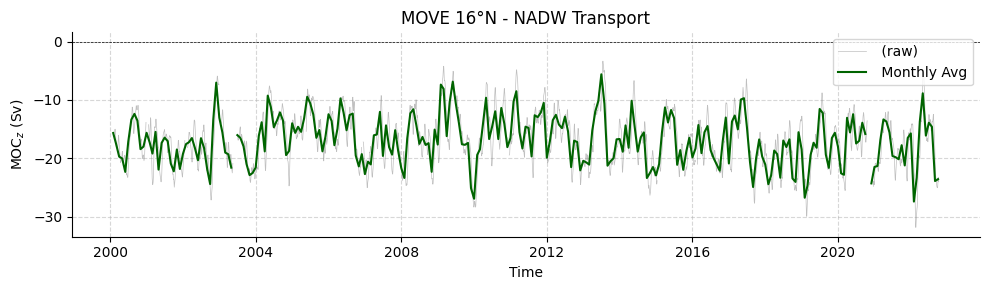

In [44]:
from amocatlas import plotters

# Plot MOVE timeseries
plotters.plot_amoc_timeseries(
    data=[ds],
    varnames=["MOC"],
    labels=[""],
    colors=["darkgreen"],
    resample_monthly=True,
    plot_raw=True,
    title="MOVE 16°N - NADW Transport"
)
plt.savefig('../plots/timeseries.png')
plt.savefig('../plots/timeseries.pdf')
plt.show()